In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm


# Diffusion continue 0D : VP-SDE conditionnel simple

Ce notebook reprend le dataset 0D du notebook discret, mais remplace la chaine DDPM
\(x_0 \to x_1 \to \cdots \to x_T\) par un processus en temps continu
\(t \in [0,1]\). Le forward utilisé est le **Variance Preserving SDE**

$$
\mathrm{d}x_t = -\frac{1}{2}\beta(t)x_t\,\mathrm{d}t + \sqrt{\beta(t)}\,\mathrm{d}w_t,
\qquad t\in[0,1].
$$

Cette SDE lineaire se resout explicitement par facteur integrant. En posant

$$
B(t)=\int_0^t \beta(s)\,\mathrm{d}s,
$$

on obtient

$$
x_t = e^{-\frac12 B(t)}x_0
+ \int_0^t e^{-\frac12 [B(t)-B(s)]}\sqrt{\beta(s)}\,\mathrm{d}w_s.
$$

Le second terme est une integrale stochastique gaussienne de moyenne nulle et de variance
\(1-e^{-B(t)}\). Donc

$$
x_t = \sqrt{\bar\alpha(t)}x_0 + \sqrt{1-\bar\alpha(t)}\,\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I),
\qquad
\bar\alpha(t)=e^{-B(t)}.
$$

Sa marginale conditionnelle est donc connue exactement :

$$
q(x_t\mid x_0)=\mathcal{N}\left(\sqrt{\bar\alpha(t)}x_0,\,[1-\bar\alpha(t)]I\right).
$$

La simulation inverse reste numeriquement discretisee, comme toute integration d'EDO/SDE,
mais le modele appris voit un temps reel continu et non une classe de timestep.

# Création du Dataset

> torch.distributions.Categorical(torch.tensor([1, 2]))

Définie 2 variable aléatoire discrete choisit entre K catégorie (ici K=2)
Avec le tenseur [1, 2] les poids sont alors,
$$ \pi_1 = \frac{1}{1+2}=\frac{1}{3} \quad \pi_2 = \frac{2}{1+2}=\frac{2}{3} $$

> torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))

Définie 2 lois normales definie par des tenseurs 
$$ \mathcal{N}( \mu_1=-4, \sigma_1=1) \quad \mathcal{N}(\mu_2=4, \sigma_2=1) $$

> data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily

Permet de mélanger ces distributions de sorte a avoir, 
$$ q(x_0) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x|\mu_k,\sigma_k)

In [2]:
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([1000, 1]))

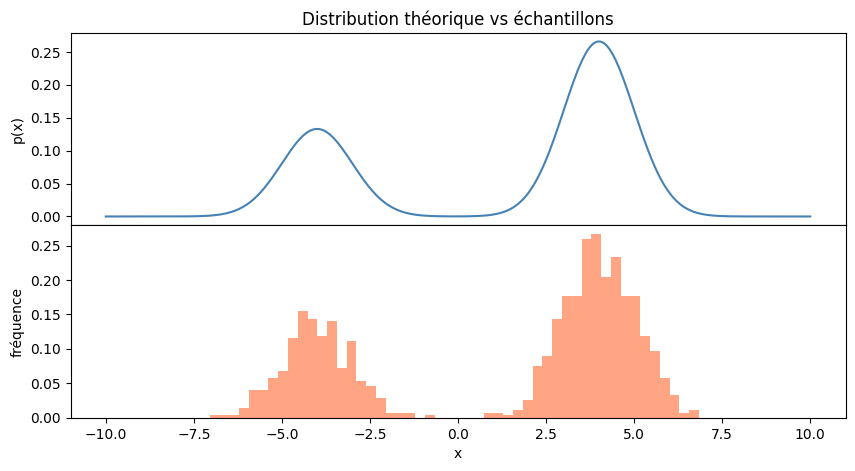

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# --- ax[0] : la vraie densité (PDF) ---
x = torch.linspace(-10, 10, 500)                # grille de 500 points entre -10 et 10
pdf = data_distribution.log_prob(x).exp()       # p(x) = exp(log p(x)), car torch donne toujour le log de la proba 
ax[0].plot(x.numpy(), pdf.numpy(), color='steelblue')
ax[0].set_title('Distribution théorique vs échantillons')
ax[0].set_ylabel("p(x)")

# --- ax[1] : histogramme des échantillons ---
ax[1].hist(dataset, bins=50, density=True, color='coral', alpha=0.7) # bins : nombre de barres de l'histograme
# density=True normalise l'histogramme pour que l'aire = 1,
# ce qui le rend comparable à la PDF du dessus
ax[1].set_xlabel("x")
ax[1].set_ylabel("fréquence")

fig.subplots_adjust(hspace=0)
plt.show()

## Processus forward continu

On choisit un calendrier lineaire

$$\beta(t)=\beta_{\min}+t(\beta_{\max}-\beta_{\min}).$$

Alors

$$
B(t)=\int_0^t \beta(s)ds
=\beta_{\min}t+\frac{1}{2}(\beta_{\max}-\beta_{\min})t^2,
$$

et donc

$$
\bar\alpha(t)
=\exp\left[-\beta_{\min}t-\frac{1}{2}(\beta_{\max}-\beta_{\min})t^2\right].
$$

Le forward peut donc etre echantillonne directement a n'importe quel temps reel :

$$x_t=\sqrt{\bar\alpha(t)}x_0+\sqrt{1-\bar\alpha(t)}\epsilon,\quad \epsilon\sim\mathcal{N}(0,I).$$

C'est la difference conceptuelle avec le DDPM discret precedent : on ne construit plus une trajectoire Markovienne par multiplication de \(T\) noyaux gaussiens.

In [4]:
# Parametres du VP-SDE continu.
T_END = 1.0
BETA_MIN = 0.1
BETA_MAX = 20.0
EPS_TIME = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = dataset.to(DEVICE)


def beta_t(t):
    return BETA_MIN + t * (BETA_MAX - BETA_MIN)


def int_beta_t(t):
    return BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t**2


def alpha_bar_t(t):
    return torch.exp(-int_beta_t(t))


def q_sample_continuous(x0, t, eps=None):
    """Echantillonne q(x_t | x_0) pour t reel dans [0, 1]."""
    if eps is None:
        eps = torch.randn_like(x0)
    abar = alpha_bar_t(t).view(-1, 1)
    xt = torch.sqrt(abar) * x0 + torch.sqrt(1.0 - abar) * eps
    return xt, eps


with torch.no_grad():
    alpha_bar_1 = alpha_bar_t(torch.tensor([T_END], device=DEVICE)).item()
    snr_1 = alpha_bar_1 / (1.0 - alpha_bar_1)
print(f"alpha_bar(1)={alpha_bar_1:.3e}, SNR(1)={snr_1:.3e}")

alpha_bar(1)=4.319e-05, SNR(1)=4.319e-05


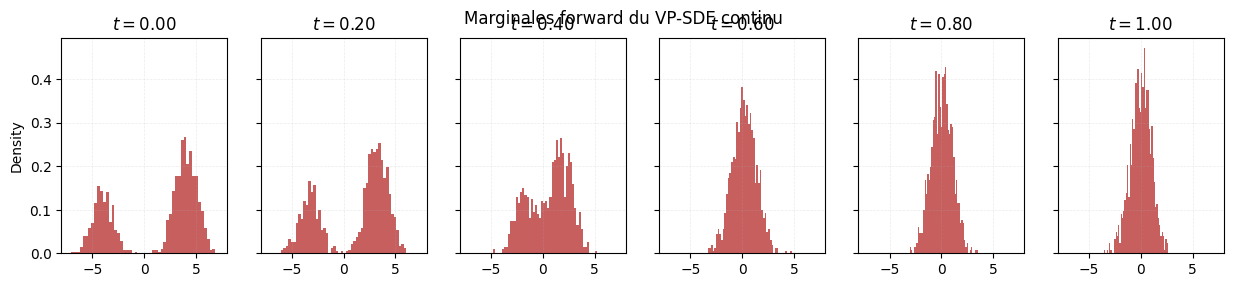

In [ ]:
def forward_snapshots(data, times):
    snapshots = []
    for t_value in times:
        t = torch.full((data.shape[0],), float(t_value), device=data.device)
        xt, _ = q_sample_continuous(data, t)
        snapshots.append(xt.detach().cpu())
    return snapshots

plot_times = torch.linspace(0.0, 1.0, 6)
snapshots = forward_snapshots(dataset, plot_times)

fig, axes = plt.subplots(1, len(plot_times), figsize=(15, 2.8), sharex=True, sharey=True)
for axis, t_value, snap in zip(axes, plot_times, snapshots):
    axis.hist(snap[:, 0], bins=50, density=True, color="firebrick", alpha=0.72)
    axis.set_title(fr"$t={float(t_value):.2f}$")
    axis.set_xlim(-8, 8)
    axis.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
axes[0].set_ylabel("Density")
fig.suptitle("Marginales forward du VP-SDE continu")
plt.show()

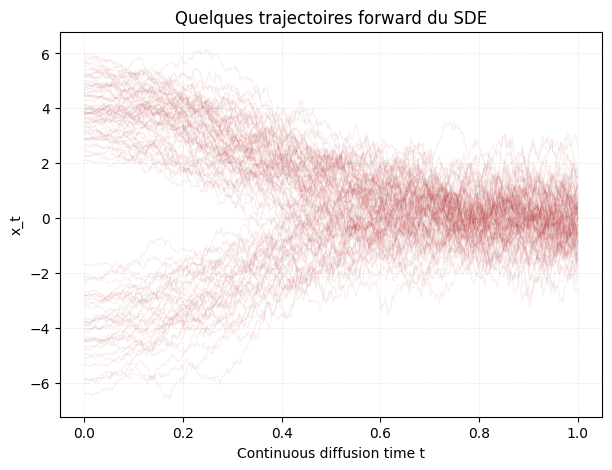

In [ ]:
# Visualisation de trajectoires forward par Euler-Maruyama.
# Elle sert uniquement a montrer des chemins SDE; l'entrainement utilise la marginale exacte.

def simulate_forward_paths(x0, n_steps=500):
    dt = T_END / n_steps
    xt = x0.clone()
    history = [xt.detach().cpu()]
    for i in range(n_steps):
        t = torch.full((x0.shape[0], 1), i * dt, device=x0.device)
        beta = beta_t(t)
        drift = -0.5 * beta * xt
        diffusion = torch.sqrt(beta)
        xt = xt + drift * dt + diffusion * torch.sqrt(torch.tensor(dt, device=x0.device)) * torch.randn_like(xt)
        history.append(xt.detach().cpu())
    return torch.stack(history)

forward_paths = simulate_forward_paths(dataset[:100], n_steps=500)
fig, ax = plt.subplots(figsize=(7, 5))
for path in forward_paths[:, :, 0].T:
    ax.plot(torch.linspace(0, 1, forward_paths.shape[0]), path, color="firebrick", alpha=0.08, linewidth=0.8)
ax.set_xlabel("Continuous diffusion time t")
ax.set_ylabel("x_t")
ax.set_title("Quelques trajectoires forward du SDE")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
plt.show()

# Entrainement du score continu

Pour un VP-SDE, le reverse-time SDE s'ecrit formellement

$$
\mathrm{d}x_t = \left[-\frac{1}{2}\beta(t)x_t - \beta(t)\nabla_x \log p_t(x_t)\right]\mathrm{d}t
+ \sqrt{\beta(t)}\,\mathrm{d}\bar w_t,
$$

integre de \(t=1\) vers \(t=0\). Il faut donc approximer le score
\(s_\theta(x_t,t)\approx \nabla_x\log p_t(x_t)\).

Comme la marginale conditionnelle est gaussienne,

$$
\nabla_{x_t}\log q(x_t\mid x_0)= -\frac{\epsilon}{\sqrt{1-\bar\alpha(t)}}.
$$

On entraine ici le reseau a predire \(\epsilon\), ce qui est equivalent a apprendre le score par

$$s_\theta(x_t,t)= -\frac{\epsilon_\theta(x_t,t)}{\sqrt{1-\bar\alpha(t)}}.$$

In [ ]:
class ContinuousEpsilonModel(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(4, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, 1),
        )

    def forward(self, x, t):
        if t.ndim == 1:
            t = t[:, None]
        # Encodage temporel minimal, continu. Pour un probleme 0D, deux frequences suffisent.
        features = torch.cat([x, t, torch.sin(2 * torch.pi * t), torch.cos(2 * torch.pi * t)], dim=1)
        return self.net(features)


def continuous_diffusion_loss(model, x0):
    t = torch.rand(x0.shape[0], device=x0.device) * (1.0 - EPS_TIME) + EPS_TIME
    eps = torch.randn_like(x0)
    xt, eps = q_sample_continuous(x0, t, eps)
    eps_pred = model(xt, t)
    return torch.mean((eps_pred - eps) ** 2)


eps_model = ContinuousEpsilonModel().to(DEVICE)
optim = torch.optim.AdamW(eps_model.parameters(), lr=2e-3, weight_decay=1e-6)

In [ ]:
loss_history = []
bar = tqdm(range(2500))
for e in bar:
    optim.zero_grad()
    loss = continuous_diffusion_loss(eps_model, dataset)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(eps_model.parameters(), max_norm=1.0)
    optim.step()

    loss_history.append(loss.item())
    if e % 25 == 0:
        bar.set_description(f"Loss: {loss.item():.4f}")

Loss: 0.3811: 100%|██████████| 2500/2500 [00:10<00:00, 249.15it/s]


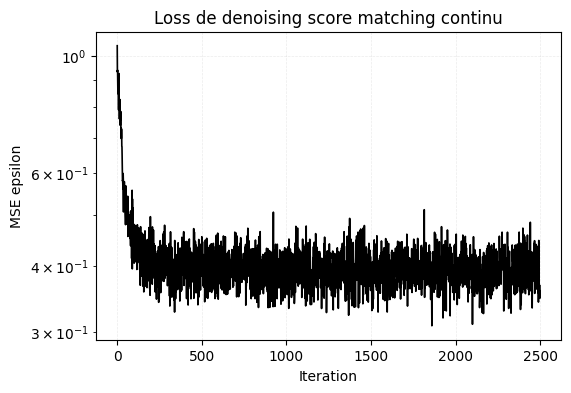

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history, color="black", linewidth=1.2)
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE epsilon")
ax.set_title("Loss de denoising score matching continu")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
plt.show()

# Generation par reverse SDE

L'equation inverse est continue mais son integration numerique utilise un pas \(\Delta t\). Augmenter
`n_steps` reduit l'erreur de discretisation du solveur, sans changer la nature continue du modele appris.

In [ ]:
@torch.no_grad()
def score_model(model, x, t):
    abar = alpha_bar_t(t).view(-1, 1)
    eps_pred = model(x, t)
    return -eps_pred / torch.sqrt((1.0 - abar).clamp_min(1e-5))


@torch.no_grad()
def sample_reverse_sde(model, count, n_steps=600):
    model.eval()
    xt = torch.randn(count, 1, device=DEVICE)
    history = [xt.detach().cpu()]
    dt = 1.0 / n_steps

    for i in range(n_steps, 0, -1):
        t_value = max(i / n_steps, EPS_TIME)
        t = torch.full((count,), t_value, device=DEVICE)
        beta = beta_t(t).view(-1, 1)
        score = score_model(model, xt, t)

        # Reverse-time Euler-Maruyama, ecrit avec un pas positif dt vers t-dt.
        drift_reverse = -0.5 * beta * xt - beta * score
        noise = torch.randn_like(xt) if i > 1 else torch.zeros_like(xt)
        xt = xt - drift_reverse * dt + torch.sqrt(beta * dt) * noise

        if i % max(1, n_steps // 200) == 0 or i == 1:
            history.append(xt.detach().cpu())
    return torch.stack(history)


samps = sample_reverse_sde(eps_model, 1000, n_steps=600)

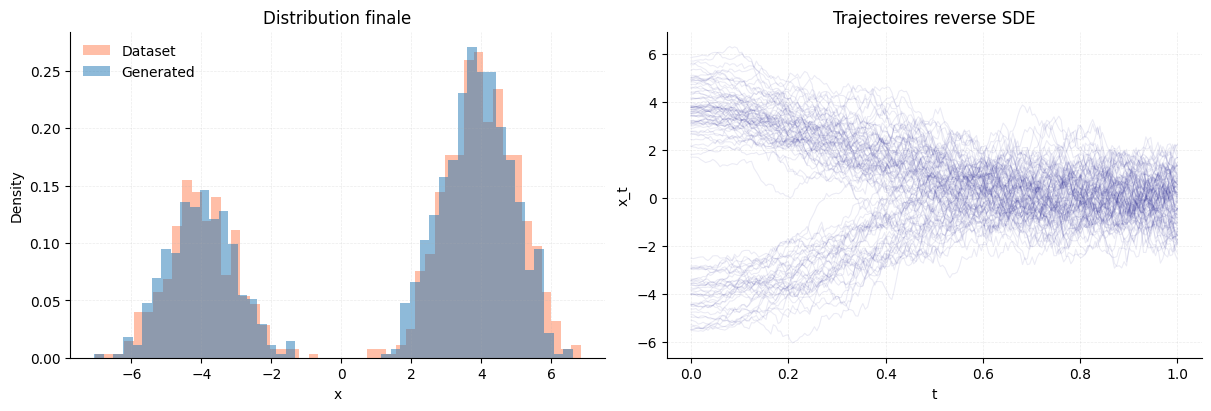

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax[0].hist(dataset.detach().cpu()[:, 0], bins=50, density=True, color="coral", alpha=0.5, label="Dataset")
ax[0].hist(samps[-1, :, 0], bins=50, density=True, color="tab:blue", alpha=0.5, label="Generated")
ax[0].set_title("Distribution finale")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Density")
ax[0].legend(frameon=False)

reverse_time = torch.linspace(1, 0, samps.shape[0])
for path in samps[:, :, 0].T[:100]:
    ax[1].plot(reverse_time, path, color="navy", alpha=0.08, linewidth=0.8)
ax[1].set_title("Trajectoires reverse SDE")
ax[1].set_xlabel("t")
ax[1].set_ylabel("x_t")

for axis in ax:
    axis.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
plt.show()

## Densite exacte et score analytique du melange bruite

Comme le dataset est un melange de deux gaussiennes 1D, on peut calculer la densite marginale exacte de \(x_t\). Si
\(x_0\sim\sum_k \pi_k\mathcal{N}(\mu_k,\sigma_k^2)\), alors

$$x_t\sim\sum_k \pi_k\mathcal{N}\left(\sqrt{\bar\alpha(t)}\mu_k,\bar\alpha(t)\sigma_k^2+1-\bar\alpha(t)\right).$$

Cela donne un controle utile pour verifier qualitativement le score appris.

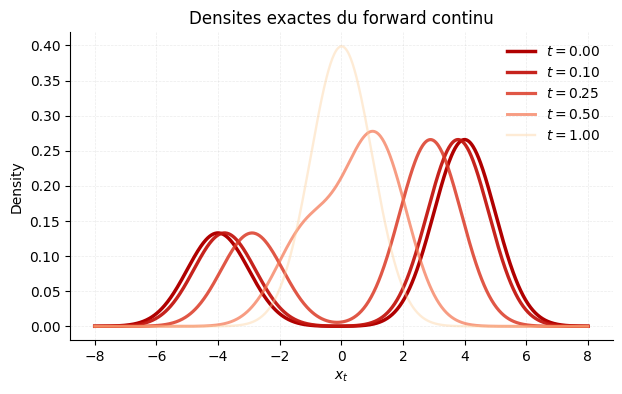

In [64]:
weights = np.array([1.0 / 3.0, 2.0 / 3.0])
means = np.array([-4.0, 4.0])
stds = np.array([1.0, 1.0])
x_grid = np.linspace(-8, 8, 800)

# Palette temporelle: clair pres des donnees, plus dense pres du bruit.
FORWARD_CMAP = plt.get_cmap("OrRd")
REVERSE_CMAP = plt.get_cmap("Blues")


def time_color(t_value):
    return FORWARD_CMAP(0.88 - 0.60 * float(t_value))


def time_color_b(t_value):
    return REVERSE_CMAP(0.90 - 0.55 * float(t_value))


def style_axes(ax):
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def alpha_bar_np(t):
    return np.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t**2))


def normal_pdf_np(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (np.sqrt(2 * np.pi) * std)


def mixture_pdf(x, t):
    abar = alpha_bar_np(t)
    pdf = np.zeros_like(x, dtype=float)
    for w, mu, sigma in zip(weights, means, stds):
        mean_t = np.sqrt(abar) * mu
        var_t = abar * sigma**2 + (1.0 - abar)
        pdf += w * normal_pdf_np(x, mean_t, np.sqrt(var_t))
    return pdf


fig, ax = plt.subplots(figsize=(7, 4))
for t_value in [0.0, 0.1, 0.25, 0.5, 1.0]:
    ax.plot(
        x_grid,
        mixture_pdf(x_grid, t_value),
        color=time_color(t_value),
        linewidth=2.5 - 0.8 * t_value,
        alpha=1-0.6 * t_value,
        label=fr"$t={t_value:.2f}$",
    )
ax.set_xlabel(r"$x_t$")
ax.set_ylabel("Density")
ax.set_title("Densites exactes du forward continu")
ax.legend(frameon=False)
style_axes(ax)
plt.show()

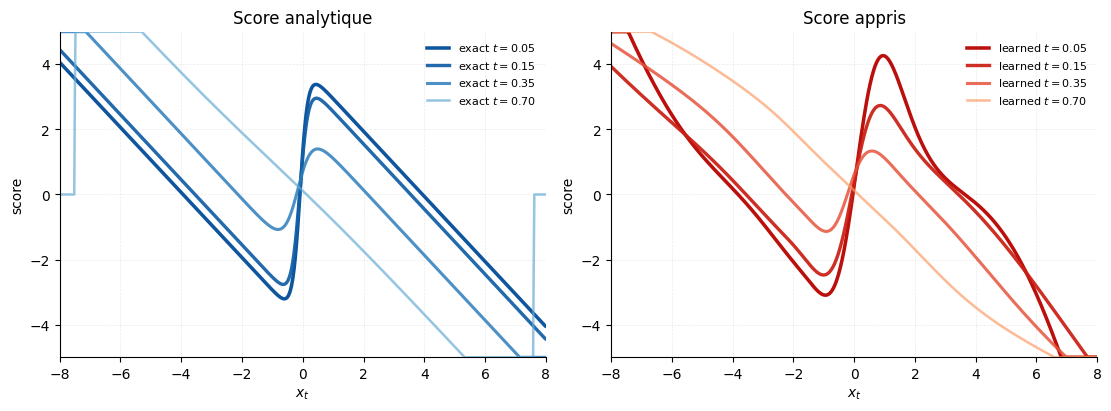

In [72]:
@torch.no_grad()
def learned_score_on_grid(model, x_values, t_value):
    x = torch.tensor(x_values[:, None], dtype=torch.float32, device=DEVICE)
    t = torch.full((x.shape[0],), float(t_value), device=DEVICE)
    return score_model(model, x, t).detach().cpu().numpy()[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for t_value in [0.05, 0.15, 0.35, 0.7]:
    p = mixture_pdf(x_grid, t_value)
    exact_score = np.gradient(np.log(np.maximum(p, 1e-12)), x_grid)
    pred_score = learned_score_on_grid(eps_model, x_grid, t_value)
    axes[0].plot(
        x_grid,
        np.clip(exact_score, -5, 5),
        color=time_color_b(t_value),
        linewidth=2.6 - 1.1 * t_value,
        alpha=1 - 0.45 * t_value,
        label=fr"exact $t={t_value:.2f}$",
    )
    axes[1].plot(
        x_grid,
        np.clip(pred_score, -5, 5),
        color=time_color(t_value),
        linewidth=2.6 - 1.1 * t_value,
        alpha=1.0 - 0.45 * t_value,
        label=fr"learned $t={t_value:.2f}$",
    )

for axis in axes:
    axis.set_xlabel(r"$x_t$")
    axis.set_ylabel(r"score")
    axis.set_xlim(-8, 8)
    axis.set_ylim(-5, 5)
    axis.legend(frameon=False, fontsize=8)
    style_axes(axis)
axes[0].set_title("Score analytique")
axes[1].set_title("Score appris")
plt.show()